# 🚀 Entraînement DQN — Sailing Challenge

Ce notebook entraîne un agent **Double DQN** (numpy pur, compatible Codabench) pour naviguer un voilier sur une grille 128×128.

## Plan
1. Configuration et imports
2. Vérification de l'environnement
3. Lancement de l'entraînement
4. Visualisation de la courbe d'apprentissage
5. Évaluation sur les 3 scénarios d'entraînement
6. Génération du fichier de soumission Codabench

In [22]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Ajouter la racine du projet au path
ROOT = os.path.abspath('..')   # adapter si besoin
sys.path.insert(0, ROOT)

print("ROOT:", ROOT)
print("Python:", sys.version.split()[0])

ROOT: /home/onyxia/work/stable_v2_RL_sailing_challenge
Python: 3.13.12


## 1. Vérification de l'environnement

On s'assure que tout s'importe correctement et qu'on comprend la structure de l'observation.

In [23]:
from src.env_sailing    import SailingEnv
from src.wind_scenarios import get_wind_scenario
from src.features       import extract_features, N_FEATURES

# Créer un environnement de test
env = SailingEnv(**get_wind_scenario('training_1'))
obs, info = env.reset(seed=42)

print(f"Observation brute : {obs.shape} valeurs")
print(f"  - Position  (x, y)  : {obs[0]:.1f}, {obs[1]:.1f}")
print(f"  - Vitesse  (vx, vy) : {obs[2]:.3f}, {obs[3]:.3f}")
print(f"  - Vent local (wx,wy): {obs[4]:.3f}, {obs[5]:.3f}")
print()
feat = extract_features(obs)
print(f"Features compressées : {feat.shape} valeurs  (au lieu de {obs.shape[0]})")
print(f"Feature range : [{feat.min():.3f}, {feat.max():.3f}]")

Observation brute : (49158,) valeurs
  - Position  (x, y)  : 64.0, 0.0
  - Vitesse  (vx, vy) : 0.000, 0.000
  - Vent local (wx,wy): -6.076, 7.943

Features compressées : (192,) valeurs  (au lieu de 49158)
Feature range : [-0.999, 0.992]


In [24]:

import src
print(src)


<module 'src' from '/home/onyxia/work/stable_v2_RL_sailing_challenge/src/__init__.py'>


In [25]:
# Test rapide de la physique : quelques steps à la main

from src.agents.agent_super_naive import SuperNaiveAgent

naive = SuperNaiveAgent()
obs, _ = env.reset(seed=0)
total_r = 0
for step in range(500):
    action = naive.act(obs)
    obs, r, term, trunc, info = env.step(action)
    total_r += r
    if term or trunc:
        break

print(f"SuperNaive : {step+1} steps, reward={total_r}, "
      f"goal_reached={info['position'][1] >= 126}")

SuperNaive : 171 steps, reward=100.0, goal_reached=True


## 2. Lancement de l'entraînement

L'entraînement tourne sur les **3 scénarios de vent** en rotation pour forcer la généralisation.

⚠️ **Durée estimée** : ~25–35 min pour 4 000 épisodes (CPU seul — pas besoin de GPU ici).

💡 **Astuce** : un checkpoint est sauvegardé tous les 100 épisodes dans `models/checkpoint.npz`.  
Tu peux interrompre et relancer : l'entraînement reprend automatiquement là où il s'est arrêté.

In [26]:
from src.train_dqn import train

net, rewards = train(
    n_episodes    = 4000,
    n_hidden1     = 256,
    n_hidden2     = 128,
    lr            = 5e-4,
    gamma         = 0.995,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.9975,
    buffer_size   = 50_000,
    batch_size    = 256,
    min_buffer    = 1_000,
    target_update_freq = 200,
    save_dir      = os.path.join(ROOT, 'models'),
    seed          = 42,
)

✓ Reprise depuis l'épisode 2300 | ε=0.0500

  DQN Training — Sailing Challenge
  Features    : 192
  Architecture: 192 → 256 → 128 → 9
  Episodes    : 4000  |  LR=0.0005  |  γ=0.995
  Buffer      : 50000  |  Batch=256
  Scénarios   : ['training_1', 'training_2', 'training_3']



Ep  2400/4000 | training_3   | AvgRew=  95.0 | Success=95.0% | ε=0.0500 | Steps=531,696 | ETA=20min
  ✓ Nouveau meilleur modèle sauvegardé (score=95.00)
Ep  2500/4000 | training_1   | AvgRew=  99.0 | Success=99.0% | ε=0.0500 | Steps=541,521 | ETA=19min
  ✓ Nouveau meilleur modèle sauvegardé (score=99.00)
Ep  2600/4000 | training_2   | AvgRew=  89.0 | Success=89.0% | ε=0.0500 | Steps=555,446 | ETA=21min
Ep  2700/4000 | training_3   | AvgRew= 100.0 | Success=100.0% | ε=0.0500 | Steps=565,809 | ETA=19min
  ✓ Nouveau meilleur modèle sauvegardé (score=100.00)
Ep  2800/4000 | training_1   | AvgRew=  99.0 | Success=99.0% | ε=0.0500 | Steps=575,114 | ETA=17min
Ep  2900/4000 | training_2   | AvgRew=  98.0 | Success=98.0% | ε=0.0500 | Steps=584,893 | ETA=16min
Ep  3000/4000 | training_3   | AvgRew=  99.0 | Success=99.0% | ε=0.0500 | Steps=594,150 | ETA=14min
Ep  3100/4000 | training_1   | AvgRew=  99.0 | Success=99.0% | ε=0.0500 | Steps=603,500 | ETA=12min
Ep  3200/4000 | training_2   | AvgRew= 

## 3. Courbe d'apprentissage

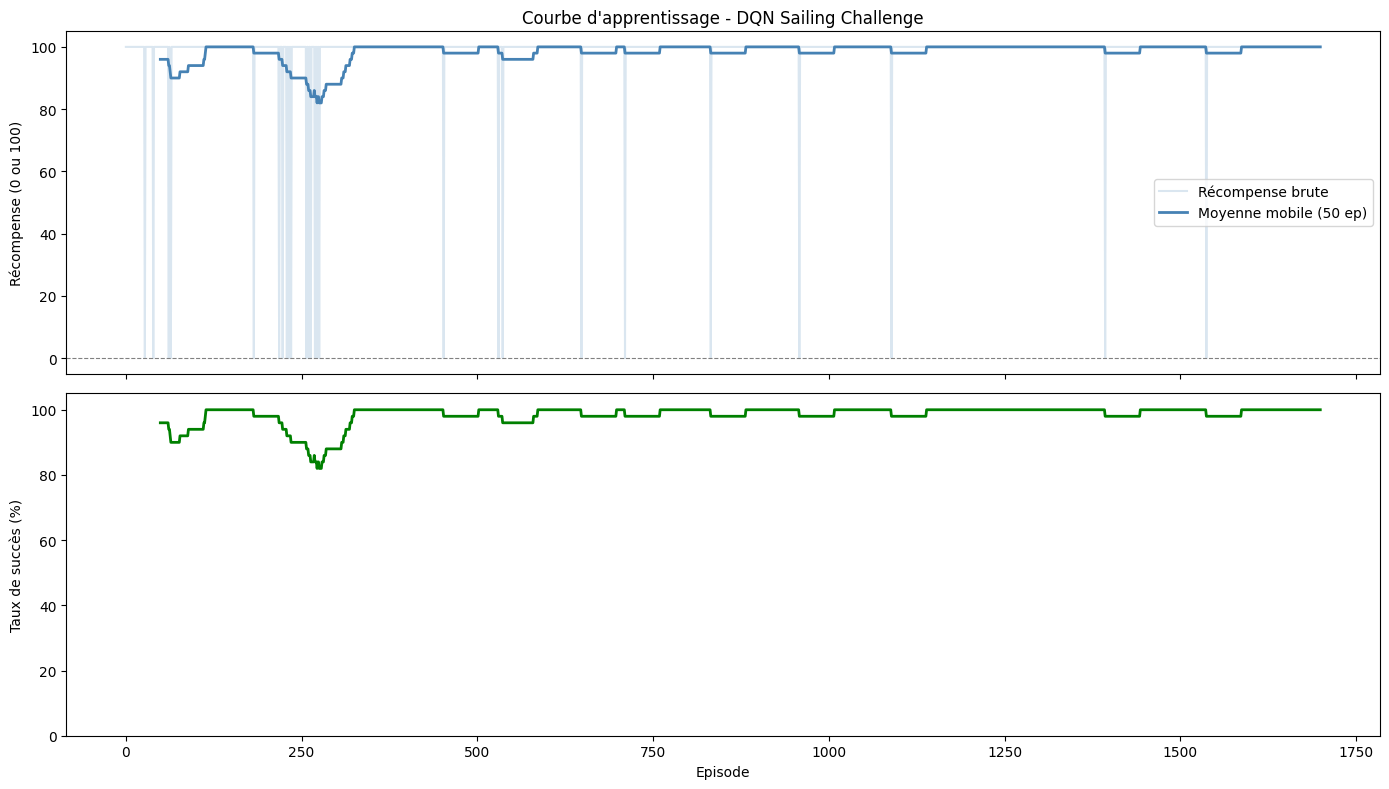

Succès globaux : 98.4%
Succès 500 derniers : 99.6%


In [27]:
# Charger l'historique (utile si on reprend après interruption)
rewards_path = os.path.join(ROOT, 'models', 'rewards_history.npy')
if os.path.exists(rewards_path):
    rewards = list(np.load(rewards_path))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Récompenses brutes ──
window = 50
r_arr = np.array(rewards)
rolling_mean = np.convolve(r_arr, np.ones(window)/window, mode='valid')
axes[0].plot(r_arr, alpha=0.2, color='steelblue', label='Récompense brute')
axes[0].plot(np.arange(window-1, len(r_arr)), rolling_mean,
             color='steelblue', linewidth=2, label=f'Moyenne mobile ({window} ep)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Récompense (0 ou 100)')
axes[0].set_title("Courbe d'apprentissage - DQN Sailing Challenge")
axes[0].legend()

# ── Taux de succès ──
success = np.array([r > 0 for r in rewards], dtype=float)
rolling_success = np.convolve(success, np.ones(window)/window, mode='valid') * 100
axes[1].plot(np.arange(window-1, len(success)), rolling_success,
             color='green', linewidth=2)
axes[1].set_ylabel('Taux de succès (%)')
axes[1].set_xlabel('Episode')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'models', 'learning_curve.png'), dpi=120)
plt.show()
print(f"Succès globaux : {success.mean()*100:.1f}%")
print(f"Succès 500 derniers : {success[-500:].mean()*100:.1f}%")

## 4. Évaluation sur les scénarios d'entraînement

On évalue le meilleur modèle sauvegardé sur les 3 scénarios (ε=0, politique greedy).

In [28]:
from src.mlp_numpy  import MLP
from src.features   import N_FEATURES, extract_features

N_ACTIONS = 9
N_HIDDEN1, N_HIDDEN2 = 256, 128

# Charger le meilleur modèle
best_model = MLP(N_FEATURES, N_HIDDEN1, N_HIDDEN2, N_ACTIONS)
best_model.load(os.path.join(ROOT, 'models', 'best_agent.npz'))
print("Modèle chargé ✓")

def evaluate(model, scenario_name, n_seeds=20, verbose=True):
    """Évalue le modèle sur n_seeds seeds du scénario donné."""
    env = SailingEnv(**get_wind_scenario(scenario_name))
    scores, steps_list, successes = [], [], []

    for seed in range(n_seeds):
        obs, _ = env.reset(seed=seed)
        total_r, n_steps, done = 0.0, 0, False
        while not done and n_steps < 500:
            feat   = extract_features(obs)
            action = int(np.argmax(model.forward(feat)))
            obs, r, term, trunc, _ = env.step(action)
            total_r += r
            n_steps += 1
            done = term or trunc

        # Score avec discount (comme Codabench)
        disc_score = total_r * (0.995 ** n_steps) if total_r > 0 else 0.0
        scores.append(disc_score)
        steps_list.append(n_steps)
        successes.append(total_r > 0)

    if verbose:
        print(f"  {scenario_name:12s} | Score={np.mean(scores):.2f} | "
              f"Success={np.mean(successes)*100:.0f}% | "
              f"Steps={np.mean(steps_list):.0f}")
    return scores, steps_list, successes

print("\nÉvaluation sur les 3 scénarios d'entraînement (20 seeds chacun) :")
all_scores = []
for sc in ['training_1', 'training_2', 'training_3']:
    sc_scores, _, _ = evaluate(best_model, sc, n_seeds=20)
    all_scores.extend(sc_scores)

print(f"\n  Score global (60 seeds) : {np.mean(all_scores):.2f}")

Modèle chargé ✓

Évaluation sur les 3 scénarios d'entraînement (20 seeds chacun) :
  training_1   | Score=52.90 | Success=100% | Steps=127
  training_2   | Score=66.37 | Success=100% | Steps=82
  training_3   | Score=77.08 | Success=100% | Steps=52

  Score global (60 seeds) : 65.45


## 5. Génération du fichier de soumission Codabench

Le script `save_agent.py` :
1. Charge les poids du meilleur modèle
2. Génère `submissions/my_agent.py` avec les poids **embarqués dans le code**
3. Crée `submissions/my_submission.zip` prêt à uploader sur Codabench

In [29]:
from src.save_agent import save_submission

agent_path, zip_path = save_submission(
    weights_path = os.path.join(ROOT, 'models', 'best_agent.npz'),
    output_dir   = os.path.join(ROOT, 'submissions'),
    n_hidden1    = N_HIDDEN1,
    n_hidden2    = N_HIDDEN2,
)
print(f"\nFichier de soumission prêt : {zip_path}")

Chargement des poids : /home/onyxia/work/stable_v2_RL_sailing_challenge/models/best_agent.npz
✓ Agent généré : /home/onyxia/work/stable_v2_RL_sailing_challenge/submissions/my_agent.py
✓ ZIP de soumission créé : /home/onyxia/work/stable_v2_RL_sailing_challenge/submissions/my_submission.zip
  Contenu du ZIP : ['my_agent.py']
  Structure ZIP correcte ✓

Fichier de soumission prêt : /home/onyxia/work/stable_v2_RL_sailing_challenge/submissions/my_submission.zip


In [30]:
# Vérification locale : importer et tester l'agent généré
import importlib.util, sys

spec   = importlib.util.spec_from_file_location("my_agent", agent_path)
module = importlib.util.module_from_spec(spec)

# Simuler l'import Codabench (remplacer evaluator.base_agent par agents.base_agent)
sys.modules['evaluator'] = type(sys)('evaluator')
sys.modules['evaluator.base_agent'] = __import__('src.agents.base_agent',
                                                   fromlist=['BaseAgent'])
spec.loader.exec_module(module)
MyAgent = module.MyAgent

# Test rapide
agent = MyAgent()
agent.seed(0)
agent.reset()

env = SailingEnv(**get_wind_scenario('training_1'))
obs, _ = env.reset(seed=999)
total_r, n_steps = 0.0, 0
while n_steps < 500:
    action = agent.act(obs)
    obs, r, term, trunc, _ = env.step(action)
    total_r += r; n_steps += 1
    if term or trunc: break

print(f"Test de l'agent généré : {n_steps} steps, reward={total_r}, success={total_r > 0}")
print("L'agent est prêt pour la soumission Codabench ✓")

Test de l'agent généré : 130 steps, reward=100.0, success=True
L'agent est prêt pour la soumission Codabench ✓


## ✅ Résumé — Checklist avant soumission

- [ ] L'entraînement a convergé (taux de succès > 50% sur les scénarios d'entraînement)
- [ ] `models/best_agent.npz` existe et a été chargé correctement
- [ ] `submissions/my_submission.zip` a été créé
- [ ] Le test local de l'agent passe (cellule ci-dessus)
- [ ] Le ZIP contient `my_agent.py` à la **racine** (pas dans un sous-dossier)

## Soumission sur Codabench

1. Va sur https://www.codabench.org/competitions/15499/
2. Clique sur **Submit** → **Upload**
3. Uploade `submissions/my_submission.zip`
4. Attends le résultat (~5 min)

Tu as jusqu'à **5 soumissions par jour** et **100 au total**.